<h1 style="color: #9f43c3ff; border-bottom: 3px solid #9f43c3ff; padding-bottom: 8px;">
AI & ML Course with BinX — Week 6 — Day 3: Backpropagation, Gradient Descent & Learning Rates
</h1>

<blockquote style="border-left: 3px solid #2e1a9aff; padding-left: 12px; margin-left: 0;">

<b>Day 3 Learning Objectives:</b>
- Understand the 4-step neural network training loop: Forward Pass, Loss Computation, Backpropagation via the Chain Rule, and Weight Updates.
- Synthesize and standardize a multi-feature binary classification dataset with train/validation partitions to evaluate gradient-based learning dynamics.
- Build and compile a multi-layer perceptron (MLP) using the Keras Sequential API with ReLU hidden layers and Sigmoid output activation.
- Implement Stochastic Gradient Descent (SGD) and systematically compare three distinct learning rate regimes (Too High, Too Low, Good / Just Right).
- Analyze training and validation loss/accuracy curves across epochs to diagnose convergence stability, underfitting, and learning rate anomalies.

</blockquote>


## <span style="color: #309c42ff">Neural Network Training Cycle: Forward Pass, Loss, Backpropagation & Weight Updates</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

Neural networks are trained iteratively through a systematic 4-stage optimization loop. Each complete cycle computes predictions, evaluates penalty errors, calculates exact analytical gradients via the chain rule, and adjusts parameters along the steepest downhill direction on the loss surface.

</blockquote>



               +---------------------------------------------+
               |                 Input Data                  |
               |             (Feature Vector X)              |
               +---------------------------------------------+
                                      |
                                      v
               +---------------------------------------------+
               |            [1] FORWARD PASS                 |
               |            To make predictions              |
               +---------------------------------------------+
                                      |
                                      v
               +---------------------------------------------+
               |              Output Prediction              |
               +---------------------------------------------+
                                      |
                                      v
               +---------------------------------------------+
               |             [2] COMPUTE LOSS                |
               +---------------------------------------------+
                                      |
                                      v
               +---------------------------------------------+
               |           [3] BACKPROPAGATION               |
               |             To find how much                |
               |      each weight contributed to the loss    |
               +---------------------------------------------+
                                      |
                                      v
               +---------------------------------------------+
               |    [4] Update the weights to reduce loss    |
               +---------------------------------------------+
                                      |
                                      +--- (Repeat for all batches & epochs) ---> Converged Model


### Detailed Stage Breakdown:

| Stage | Operation | Mathematical Representation | Description |
| :--- | :--- | :--- | :--- |
| **[1] Forward Pass** | Prediction Generation | $z = \mathbf{w} \cdot \mathbf{x} + b$<br>$\hat{y} = \sigma(z)$ | Data flows forward layer-by-layer; computes linear combinations, adds biases, and applies non-linear activations (ReLU in hidden layers, Sigmoid in the output layer). |
| **[2] Compute Loss** | Error Quantification | $\mathcal{L}_{BCE}(y, \hat{y}) = -[y\log\hat{y} + (1-y)\log(1-\hat{y})]$ | Compares the model prediction $\hat{y}$ against the ground-truth label $y$, computing an error penalty. |
| **[3] Backpropagation** | Gradient Computation | $\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \frac{\partial \mathcal{L}}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial \mathbf{w}}$ | Traverses backward through the computational graph using the **multivariate chain rule** to calculate the exact analytical gradient of the loss with respect to each weight and bias. |
| **[4] Parameter Update** | Gradient Descent | $\mathbf{w}_{t+1} = \mathbf{w}_t - \eta \frac{\partial \mathcal{L}}{\partial \mathbf{w}}$ | Adjusts all network weights and biases in the opposite direction of the gradient scaled by the **learning rate ($\eta$)** to minimize total loss. |

> **Iterative Convergence:** This 4-step sequence repeats for every mini-batch across all training epochs until the loss stabilizes at a global or local minimum.


## <span style="color: #309c42ff">3.1 Environment Setup & Reproducibility Configuration</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We import core numerical, plotting, and deep learning libraries alongside Scikit-Learn utilities. We explicitly configure global NumPy and TensorFlow random seeds (`seed = 42`) to guarantee deterministic parameter initialization and reproducible experimental runs.

</blockquote>


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


np.random.seed(42)
tf.random.set_seed(42)

## <span style="color: #309c42ff">3.2 Synthetic Dataset Generation, Feature Scaling & Validation Split</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We synthesize a controlled binary classification dataset with 1,000 samples and 10 features (8 informative, 2 redundant). We apply <code>StandardScaler</code> to ensure zero mean ($\mu = 0$) and unit variance ($\sigma = 1$), followed by an 80/20 train/validation split to monitor out-of-sample generalization.

</blockquote>


In [6]:
X, y = make_classification(
    n_samples=1000, 
    n_features=10, 
    n_informative=8, 
    n_redundant=2, 
    random_state=42
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## <span style="color: #309c42ff">3.3 Neural Network Architecture & Learning Rate Dynamics Experiment</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We construct a 2-hidden-layer network (16 and 8 units with ReLU activation) paired with a single Sigmoid output unit and Binary Cross-Entropy loss. We iteratively train freshly initialized models under three distinct Stochastic Gradient Descent (SGD) learning rate regimes ($\text{lr} = 1.5$, $\text{lr} = 0.00001$, and $\text{lr} = 0.1$) over 60 epochs to capture their training histories.

</blockquote>


In [7]:
learning_rates = {
    'Too High (lr = 2.5)': 1.5,
    'Too Low (lr = 0.0001)': 0.00001,
    'Good / Just Right (lr = 0.1)': 0.1
}

histories = {}
epochs = 60
batch_size = 32

for label, lr in learning_rates.items():
    model = Sequential([
        Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    optimizer = SGD(learning_rate=lr)
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )
    histories[label] = history.history


## <span style="color: #309c42ff">3.4 Training Diagnostics & Loss Curve Convergence Analysis</span>

<blockquote style="border-left: 3px solid #FD1D1D; padding-left: 12px; margin-left: 0;">

We plot training versus validation loss and accuracy across epochs to diagnose optimization dynamics. Comparing loss trajectories across the three learning rate settings reveals the signature behaviors of underfitting (too low), divergence/oscillation (too high), and smooth, stable convergence (optimal learning rate).

</blockquote>


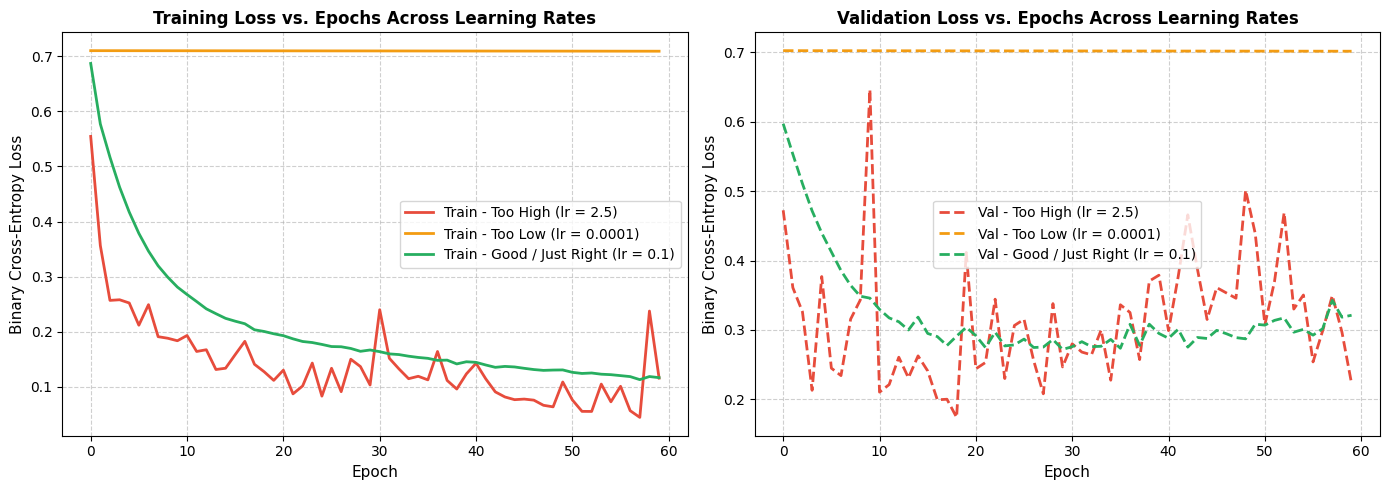

In [8]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
colors = {'Too High (lr = 2.5)': '#E74C3C', 'Too Low (lr = 0.0001)': '#F39C12', 'Good / Just Right (lr = 0.1)': '#27AE60'}

for label, hist in histories.items():
    plt.plot(hist['loss'], label=f"Train - {label}", color=colors[label], linewidth=2)

plt.title('Training Loss vs. Epochs Across Learning Rates', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Binary Cross-Entropy Loss', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)

plt.subplot(1, 2, 2)
for label, hist in histories.items():
    plt.plot(hist['val_loss'], label=f"Val - {label}", color=colors[label], linestyle='--', linewidth=2)

plt.title('Validation Loss vs. Epochs Across Learning Rates', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Binary Cross-Entropy Loss', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()


 what backpropagation computes and why the chain rule is involved?

 1. What Backpropagation does?
It efficiently computes gradients by working backward from the network's loss. Its primary purpose is to figure out exactly how much each individual weight contributed to that overall error, effectively "assigning blame" to the weights that need adjusting.

2. Why the chain rule is involved? 
Backpropagation relies on the chain rule of calculus to perform mathematical calculations backward through the layers of the network.

### What Backpropagation Computes and Why the Chain Rule is Involved

#### 1. What Backpropagation Computes
Backpropagation systematically calculates the exact analytical gradients of the loss function with respect to each weight and bias ($\frac{\partial \mathcal{L}}{\partial \mathbf{w}}$ and $\frac{\partial \mathcal{L}}{\partial b}$) by traversing backward through the network's computational graph. It quantifies how much each individual parameter contributed to the overall prediction error, enabling gradient descent optimizers to update the weights in the steepest downhill direction on the loss surface ($\mathbf{w}_{t+1} = \mathbf{w}_t - \eta \frac{\partial \mathcal{L}}{\partial \mathbf{w}}$).

#### 2. Why the Chain Rule is Involved
A neural network is mathematically structured as a sequence of nested composite functions across layers (matrix dot products, bias additions, and activation transformations). Because the loss depends on the output activation, which depends on the linear combination $z$, which in turn depends on the weights, the multivariate chain rule of calculus is required to decompose the total derivative into a product of local partial derivatives:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \frac{\partial \mathcal{L}}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial \mathbf{w}}$$
